# Dataset presentation

In [1]:
import tensorflow as tf
import pandas as pd
import os

df=pd.DataFrame()
image_paths=[]
for filename in os.listdir("Dataset"):
    if not filename.endswith("_mask.png"):
        image_paths.append(os.path.join("Dataset", filename))
mask_paths=[x.split(".")[0]+"_mask.png" for x in image_paths]
df["images"]=image_paths
df["masks"]=mask_paths

In [2]:
df.describe()

,images,masks
count,1262,1262
unique,1262,1262
top,Dataset\enh_1.png,Dataset\enh_1_mask.png
freq,1,1


In [3]:
df.head(10)

,images,masks
0,Dataset\enh_1.png,Dataset\enh_1_mask.png
1,Dataset\enh_10.png,Dataset\enh_10_mask.png
2,Dataset\enh_100.png,Dataset\enh_100_mask.png
3,Dataset\enh_101.png,Dataset\enh_101_mask.png
4,Dataset\enh_102.png,Dataset\enh_102_mask.png
5,Dataset\enh_103.png,Dataset\enh_103_mask.png
6,Dataset\enh_104.png,Dataset\enh_104_mask.png
7,Dataset\enh_105.png,Dataset\enh_105_mask.png
8,Dataset\enh_106.png,Dataset\enh_106_mask.png
9,Dataset\enh_107.png,Dataset\enh_107_mask.png


Text(0.5, 1.0, 'Mask')

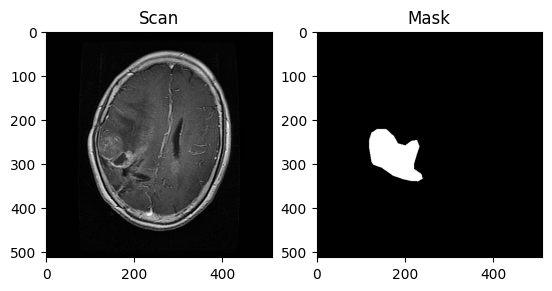

In [4]:
import matplotlib.pyplot as plt
f, ax=plt.subplots(1,2)
ax[0].imshow(plt.imread(df["images"][2]),cmap='gray')
ax[0].set_title("Scan")
ax[1].imshow(plt.imread(df["masks"][2]),cmap='gray')
ax[1].set_title("Mask")

Text(0.5, 1.0, 'Mask')

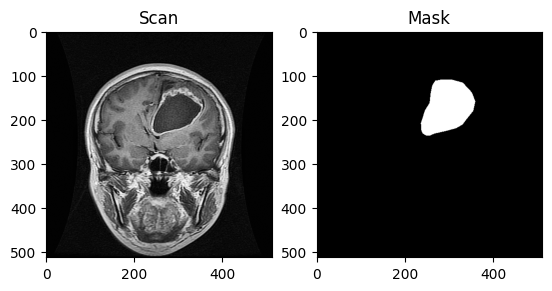

In [5]:
import matplotlib.pyplot as plt
f, ax=plt.subplots(1,2)
ax[0].imshow(plt.imread(df["images"][48]),cmap='gray')
ax[0].set_title("Scan")
ax[1].imshow(plt.imread(df["masks"][48]),cmap='gray')
ax[1].set_title("Mask")

In [6]:
from PIL import Image
img_shapes=[]
mask_shapes=[]
for i in range(len(df)):
    img=Image.open(df["images"][i])
    mask=Image.open(df["masks"][i])
    if img.size not in img_shapes:
        img_shapes.append(img.size)
    if mask.size not in mask_shapes:
        mask_shapes.append(mask.size)
print('img_shapes:',img_shapes)
print('mask_shapes:',mask_shapes)

img_shapes: [(512, 512)]
mask_shapes: [(512, 512)]


In [7]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.15,random_state=42)
train,val=train_test_split(train,test_size=0.15,random_state=42)

# Data reprocessing

In [ ]:
images=[]
masks=[]
image_path="Dataset/images"
mask_path="Dataset/masks"
image_files= sorted(os.listdir(image_path)) #important 
mask_files= sorted(os.listdir(mask_path)) 

In [ ]:
for filename in image_files:
    path=os.path.join(image_path, filename)
    img=cv2.imread(path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img=cv2.resize(img, (256, 256))
    img=img.astype('float32')/255.0
    images.append(img)

In [ ]:
for filename in mask_files:
    path=os.path.join(mask_path, filename)
    mask=cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask=cv2.resize(mask, (256, 256))
    mask=(mask > 127).astype('float32')
    mask=np.expand_dims(mask, axis=-1)
    masks.append(mask)

In [ ]:
X=np.array(images)
y=np.array(masks)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15, random_state=42)

# UNet

U-Net implementation
(https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28)
<br>
Binary Intersection Over Union(https://www.tensorflow.org/api_docs/python/tf/keras/metrics/BinaryIoU)<br>
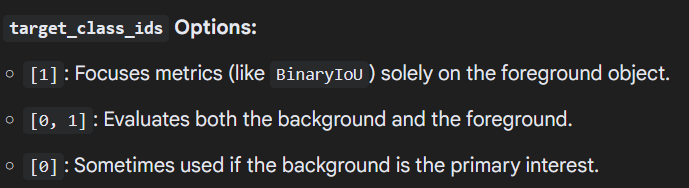

Dice score implementation was inspired by:
https://karan-jakhar.medium.com/100-days-of-code-day-7-84e4918cb72c

In [4]:
import tensorflow as tf
def dice_score(y_true, y_pred, smooth=1):
   y_true_f= tf.keras.backend.flatten(y_true)
   y_pred_f= tf.keras.backend.flatten(y_pred)
   intersection= tf.keras.backend.sum(y_true_f * y_pred_f)
   return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

In [5]:
def unet(input_shape=(256,256,3)):
    inputs=tf.keras.layers.Input(input_shape)
    c1=tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1=tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(c1)

    p1=tf.keras.layers.MaxPooling2D((2,2))(c1)
    
    c2=tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    c2=tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(c2)

    p2=tf.keras.layers.MaxPooling2D((2,2))(c2)

    c3=tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(p2)
    c3=tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(c3)

    p3=tf.keras.layers.MaxPooling2D((2,2))(c3)

    c4=tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(p3)
    c4=tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(c4)
    d4=tf.keras.layers.Dropout(0.5)(c4)
    p4=tf.keras.layers.MaxPooling2D((2,2))(d4)

    c5=tf.keras.layers.Conv2D(1024,3,activation='relu',padding='same')(p4)
    c5=tf.keras.layers.Conv2D(1024,3,activation='relu',padding='same')(c5)
    d5=tf.keras.layers.Dropout(0.5)(c5)
    
    u6=tf.keras.layers.Conv2D(512,2,activation='relu',padding='same')(tf.keras.layers.UpSampling2D((2,2))(d5))
    merge6=tf.keras.layers.concatenate([c4,u6],axis=3)

    c6=tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(merge6)
    c6=tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(c6)
    u7=tf.keras.layers.Conv2D(256,2,activation='relu',padding='same')(tf.keras.layers.UpSampling2D((2,2))(c6))
    merge7=tf.keras.layers.concatenate([c3,u7],axis=3)
    
    c7=tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(merge7)
    c7=tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(c7)
    u8=tf.keras.layers.Conv2D(128,2,activation='relu',padding='same')(tf.keras.layers.UpSampling2D((2,2))(c7))
    merge8=tf.keras.layers.concatenate([c2,u8],axis=3)

    c8=tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(merge8)
    c8=tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(c8)
    u9=tf.keras.layers.Conv2D(64,2,activation='relu',padding='same')(tf.keras.layers.UpSampling2D((2,2))(c8))
    merge9=tf.keras.layers.concatenate([c1,u9],axis=3)

    c9=tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(merge9)
    c9=tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(c9)
    c9=tf.keras.layers.Conv2D(2,3,activation='relu',padding='same')(c9)
    outputs=tf.keras.layers.Conv2D(1,1,activation='sigmoid')(c9)

    model=tf.keras.Model(inputs=inputs,outputs=outputs)
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=[dice_score])
    #we can also try with loss=tf.keras.losses.Dice()  
    return model



In [ ]:
model=unet()
model.fit(X_train,y_train,
batch_size=4,
epochs=3)

Epoch 1/3
  5/163 ━━━━━━━━━━━━━━━━━━━━ 1:25:05 32s/step - dice_score: 0.0235 - loss: 9.2347